<a href="https://colab.research.google.com/github/tiemtores/modele_IA_prev_AO/blob/main/STACK_LSTM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install cartopy xarray netCDF4 matplotlib geopandas contextily plotly tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 197.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 121.5 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, BatchNormalization, Conv2D, ZeroPadding2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [ ]:
# Chargement des données NetCDF et ERA5
ds_imerg = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/imerg2010_2020.nc", engine="h5netcdf")
ds_era5_tcrw = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/era5_tcrw/era5_tcrw_daily_sum_2010_2020.nc", engine="h5netcdf")
ds_era5_cape = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/era5_cape/era5_cape_daily_mean_2010_2020.nc", engine="h5netcdf")
ds_era5_divergence = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/era5_divergence/era5_divergence_daily_mean_2010_2020.nc", engine="h5netcdf")
ds_era5_tmp = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/era5_temp/era5_temp_daily_mean_2010_2020.nc", engine="h5netcdf")
ds_era5_rh = xr.open_dataset("/content/drive/MyDrive/Colab Notebooks/imerg_data/era5_rh/era5_rh_daily_mean_2010_2020.nc", engine="h5netcdf")

#renommer les dimensions longitude et latitude par lon et lat idem aux données imerg
ds_era5_tcrw = ds_era5_tcrw.rename({"longitude": "lon", "latitude": "lat"})
ds_era5_tmp = ds_era5_tmp.rename({"longitude": "lon", "latitude": "lat"})
ds_era5_divergence = ds_era5_divergence.rename({"longitude": "lon", "latitude": "lat"})
ds_era5_rh = ds_era5_rh.rename({"longitude": "lon", "latitude": "lat"})
ds_era5_cape = ds_era5_cape.rename({"longitude": "lon", "latitude": "lat"})


In [ ]:
# Extraction des données
imerg_precip = ds_imerg["precipitation"].fillna(0).values  # shape: (T_imerg, H_imerg, W_imerg)
era5_tcrw = ds_era5_tcrw["tcrw"].fillna(0).values  # shape: (1, 96432, 57, 113)
era5_cape = ds_era5_cape["cape"].fillna(0).values  # shape: (1, 96432, 57, 113)
era5_divergence = ds_era5_divergence["d"].fillna(0).values  # shape: (1, 96432, 57, 113)
era5_tmp = ds_era5_tmp["t"].fillna(0).values  # shape: (1, 96432, 57, 113)
era5_rh = ds_era5_rh["r"].fillna(0).values  # shape: (1, 96432, 57, 113)


# affichage des dimensions de chaque dataset
print("imerg_precip.shape:",imerg_precip.shape)
print("era5_tcrw.shape:",era5_tcrw.shape)
print("era5_cape.shape :",era5_cape.shape)
print("era5_divergence.shape:",era5_divergence.shape)
print("era5_tmp.shape :",era5_tmp.shape)
print("era5_rh.shape :",era5_rh.shape)


imerg_precip.shape: (4018, 281, 141)
era5_tcrw.shape: (4018, 57, 113)
era5_cape.shape : (4018, 57, 113)
era5_divergence.shape: (4018, 4, 57, 113)
era5_tmp.shape : (4018, 2, 57, 113)
era5_rh.shape : (4018, 4, 57, 113)


In [ ]:
# Dimension de la grille de données imerg et Interpolation ERA5 vers la grille IMERG
T_imerg, H_imerg, W_imerg = imerg_precip.shape
print(T_imerg, H_imerg, W_imerg)

import numpy as np
from scipy.ndimage import zoom

# Dimensions IMERG
T_imerg, H_imerg, W_imerg = 4018, 281, 141
# Calculate the mean over the pressure_level dimension (axis=1) for 4D ERA5 variables
era5_tmp_mean = era5_tmp.mean(axis=1)
era5_divergence_mean = era5_divergence.mean(axis=1)
era5_rh_mean = era5_rh.mean(axis=1)

# Interpolation ERA5 vers la grille IMERG for 3D arrays
# The zoom factor is (1, target_H / source_H, target_W / source_W)
# '1' preserves the time dimension
era5_tmp_int = zoom(era5_tmp_mean, (1, H_imerg / era5_tmp_mean.shape[-2], W_imerg / era5_tmp_mean.shape[-1]), order=1)
era5_div_int = zoom(era5_divergence_mean, (1, H_imerg / era5_divergence_mean.shape[-2], W_imerg / era5_divergence_mean.shape[-1]), order=1)
era5_rh_int  = zoom(era5_rh_mean, (1, H_imerg / era5_rh_mean.shape[-2], W_imerg / era5_rh_mean.shape[-1]), order=1)

# Print shapes for verification
print("era5_tmp_int.shape:", era5_tmp_int.shape)
print("era5_div_int.shape:", era5_div_int.shape)
print("era5_rh_int.shape:", era5_rh_int.shape)

# Also re-include the interpolation for era5_cape and era5_tcrw which are already 3D
# These should work with the 3-element zoom factor directly
era5_cape_int = zoom(era5_cape, (1, H_imerg / era5_cape.shape[-2], W_imerg / era5_cape.shape[-1]), order=1)
era5_tcrw_int = zoom(era5_tcrw, (1, H_imerg / era5_tcrw.shape[-2], W_imerg / era5_tcrw.shape[-1]), order=1)

print("era5_cape_int.shape:", era5_cape_int.shape)
print("era5_tcrw_int.shape:", era5_tcrw_int.shape)



4018 281 141
era5_tmp_int.shape: (4018, 281, 141)
era5_div_int.shape: (4018, 281, 141)
era5_rh_int.shape: (4018, 281, 141)
era5_cape_int.shape: (4018, 281, 141)
era5_tcrw_int.shape: (4018, 281, 141)


In [ ]:
# Normalisation des deux jeux de données
scaler_imerg = MinMaxScaler()
scaler_era5_rh = MinMaxScaler()
scaler_era5_cape = MinMaxScaler()
scaler_era5_tcrw = MinMaxScaler()
scaler_era5_div = MinMaxScaler()
scaler_era5_tmp = MinMaxScaler()


In [ ]:
# normalisation des données
imerg_scaled = scaler_imerg.fit_transform(imerg_precip.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)
era5_cape_scaled = scaler_era5_cape.fit_transform(era5_cape_int.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)
era5_tcrw_scaled = scaler_era5_tcrw.fit_transform(era5_tcrw_int.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)
era5_rh_scaled = scaler_era5_rh.fit_transform(era5_rh_int.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)
era5_div_scaled = scaler_era5_div.fit_transform(era5_div_int.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)
era5_tmp_scaled = scaler_era5_tmp.fit_transform(era5_tmp_int.reshape(T_imerg, -1)).reshape(T_imerg, H_imerg, W_imerg, 1)


In [ ]:
# Fusion des données en entrée multicanal
combined_data = np.concatenate([era5_cape_scaled,era5_tcrw_scaled, era5_rh_scaled, era5_div_scaled,era5_tmp_scaled ], axis=-1)  # shape: (T, H, W, 5)



In [ ]:
n_steps = 7
X, y, dates = [], [], []
times = ds_imerg["time"].values

for i in range(n_steps, T_imerg):
    seq = []
    for j in range(i-n_steps, i):
        # On réduit chaque carte multicanal en moyennes spatiales par variable
        f_means = combined_data[j].mean(axis=(0,1))  # shape (5,)
        seq.append(f_means)

    X.append(seq)                        # (n_steps, 5)
    y.append(imerg_scaled[i].mean())     # cible = moyenne spatiale IMERG
    dates.append(times[i])

X = np.array(X)   # (N, n_steps, 5)
y = np.array(y)   # (N,)
dates = np.array(dates)

# Split train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates[split:]

print("X_train shape:", X_train.shape)  # (N_train, n_steps, 5)
print("y_train shape:", y_train.shape)  # (N_train,)

X_train shape: (3208, 7, 5)
y_train shape: (3208,)


In [ ]:
n_steps = 7   # longueur de la séquence temporelle
times = ds_imerg["time"].values

X, y, dates = [], [], []

for i in range(n_steps, T_imerg):
    # Séquence de n_steps vecteurs de features (moyenne spatiale par variable ERA5)
    seq = []
    for j in range(i-n_steps, i):
        # Moyenne spatiale de chaque variable ERA5
        f_cape = era5_cape_scaled[j].mean()
        f_tcrw = era5_tcrw_scaled[j].mean()
        f_rh   = era5_rh_scaled[j].mean()
        f_div  = era5_div_scaled[j].mean()
        f_tmp  = era5_tmp_scaled[j].mean()
        seq.append([f_cape, f_tcrw, f_rh, f_div, f_tmp])

    X.append(seq)                        # (n_steps, n_features)
    y.append(imerg_precip[i].mean())     # cible = moyenne spatiale IMERG
    dates.append(times[i])

X = np.array(X)   # (N, n_steps, n_features)
y = np.array(y)   # (N,)
dates = np.array(dates)

# Split train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates[split:]

print("X_train shape:", X_train.shape)  # (N_train, n_steps, n_features)
print("y_train shape:", y_train.shape)  # (N_train,)

X_train shape: (3208, 7, 5)
y_train shape: (3208,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[-1]

model = Sequential([
    LSTM(128, input_shape=(n_steps, n_features), return_sequences=True, activation="tanh"),
    LSTM(64, return_sequences=True, activation="tanh"),
    LSTM(32, return_sequences=False, activation="tanh"),
    Dense(64, activation="relu"),
    Dense(1, activation="linear")   # sortie scalaire = moyenne spatiale prédite
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae","mse"]
)

model.summary()

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[es],
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 7, 128)         │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,609 (518.00 KB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
91/91 - 2s - 25ms/step - loss: 9.3524 - mae: 2.4169 - mse: 9.3524 - val_loss: 7.2547 - val_mae: 2.3282 - val_mse: 7.2547
Epoch 2/20
91/91 - 1s - 6ms/step - loss: 4.0105 - mae: 1.4322 - mse: 4.0105 - val_loss: 3.3388 - val_mae: 1.3096 - val_mse: 3.3388
Epoch 3/20
91/91 - 1s - 6ms/step - loss: 3.5280 - mae: 1.3258 - mse: 3.5280 - val_loss: 3.2340 - val_mae: 1.2807 - val_mse: 3.2340
Epoch 4/20
91/91 - 1s - 6ms/step - loss: 3.5493 - mae: 1.3261 - mse: 3.5493 - val_loss: 3.0889 - val_mae: 1.2112 - val_mse: 3.0889
Epoch 5/20
91/91 - 1s - 6ms/step - loss: 3.4078 - mae: 1.3009 - mse: 3.4078 - val_loss: 3.0552 - val_mae: 1.2397 - val_mse: 3.0552
Epoch 6/20
91/91 - 1s - 6ms/step - loss: 3.4030 - mae: 1.3027 - mse: 3.4030 - val_loss: 3.0298 - val_mae: 1.2116 - val_mse: 3.0298
Epoch 7/20
91/91 - 1s - 6ms/step - loss: 3.4934 - mae: 1.3211 - mse: 3.4934 - val_loss: 3.6773 - val_mae: 1.4661 - val_mse: 3.6773
Epoch 8/20
91/91 - 1s - 6ms/step - loss: 3.4562 - mae: 1.3090 - mse: 3.4562 - val_

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Prédictions sur le jeu de test
y_pred = model.predict(X_test).flatten()

# --- Erreurs classiques ---
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

# --- Métriques pluie / pas de pluie ---
threshold = 1.0  # seuil pluie en mm (à adapter)
y_true_event = (y_test >= threshold).astype(int)
y_pred_event = (y_pred >= threshold).astype(int)

# Matrice de contingence
hits          = np.sum((y_true_event == 1) & (y_pred_event == 1))   # pluie observée et prédite
misses        = np.sum((y_true_event == 1) & (y_pred_event == 0))   # pluie observée mais non prédite
false_alarms  = np.sum((y_true_event == 0) & (y_pred_event == 1))   # pluie prédite mais non observée
correct_neg   = np.sum((y_true_event == 0) & (y_pred_event == 0))

# POD, FAR, CSI
POD = hits / (hits + misses) if (hits + misses) > 0 else 0
FAR = false_alarms / (hits + false_alarms) if (hits + false_alarms) > 0 else 0
CSI = hits / (hits + misses + false_alarms) if (hits + misses + false_alarms) > 0 else 0

# --- Résultats ---
print("Évaluation du modèle :")
print(f"MSE   : {mse:.3f}")
print(f"RMSE  : {rmse:.3f}")
print(f"MAE   : {mae:.3f}")
print(f"R²    : {r2:.3f}")
print(f"POD   : {POD:.3f}")
print(f"FAR   : {FAR:.3f}")
print(f"CSI   : {CSI:.3f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Évaluation du modèle :
MSE   : 3.158
RMSE  : 1.777
MAE   : 1.266
R²    : 0.626
POD   : 0.930
FAR   : 0.145
CSI   : 0.804


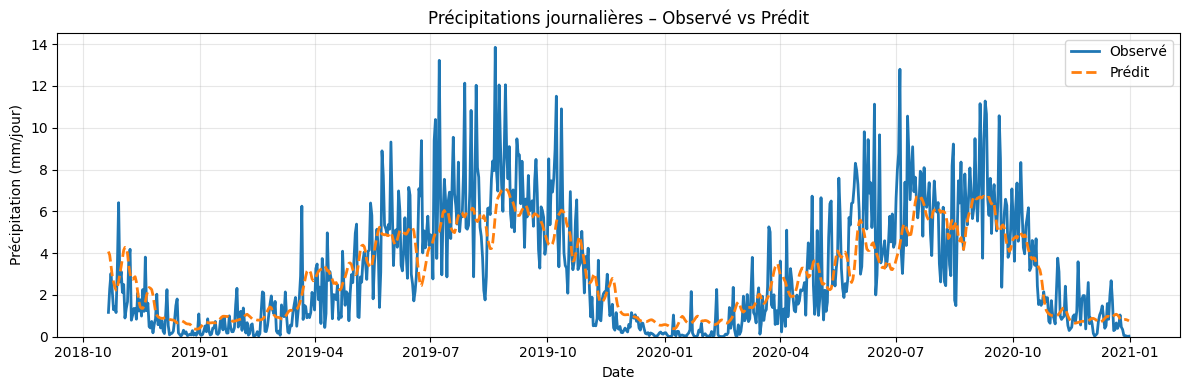

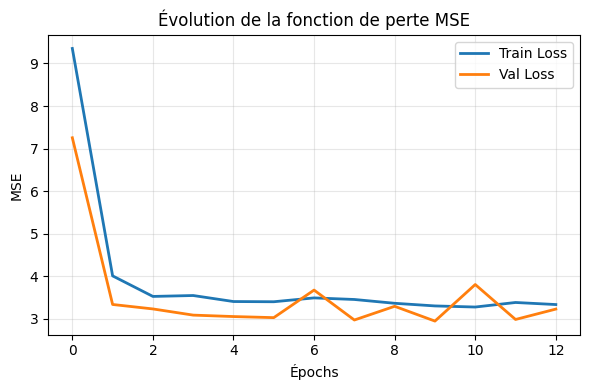

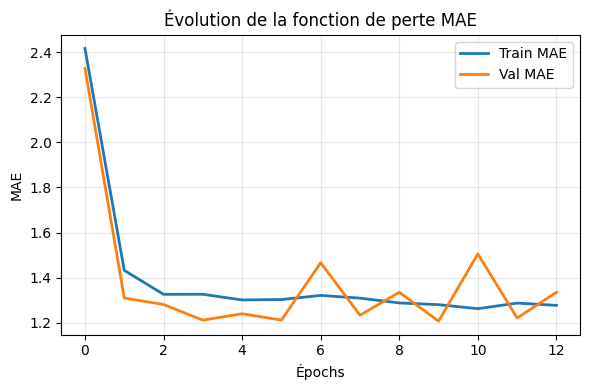

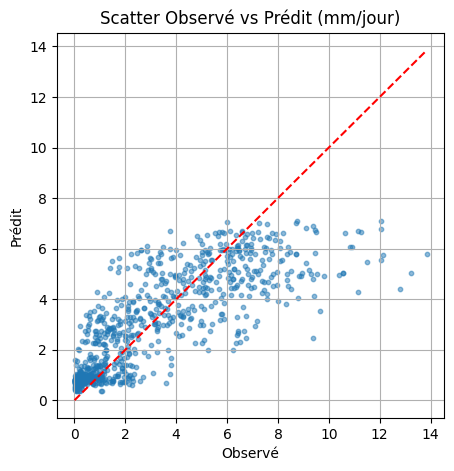

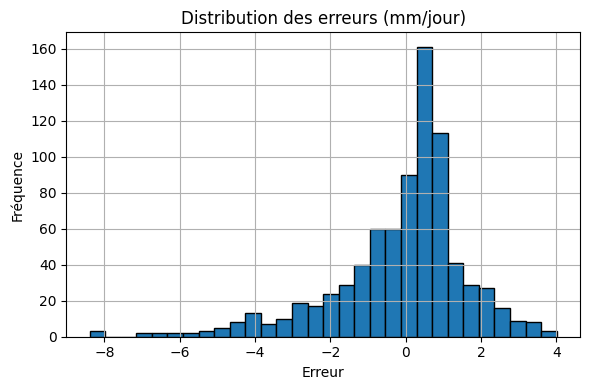

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 7.1 Observé vs Prédit dans le temps
plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test,  label="Observé",  linewidth=2)
plt.plot(dates_test, y_pred,  label="Prédit", linestyle="--", linewidth=2)
plt.title("Précipitations journalières – Observé vs Prédit")
plt.xlabel("Date"); plt.ylabel("Précipitation (mm/jour)")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(bottom=0)  # pas de valeurs négatives
plt.tight_layout(); plt.show()

# 7.2 Courbe de perte (MSE)
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title("Évolution de la fonction de perte MSE")
plt.xlabel("Épochs"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 7.3 Courbe de perte (MAE)
plt.figure(figsize=(6,4))
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
plt.title("Évolution de la fonction de perte MAE")
plt.xlabel("Épochs"); plt.ylabel("MAE")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 7.4 Scatter Observé vs Prédit
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=10, alpha=0.5)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn,mx],[mn,mx],"r--")
plt.title("Scatter Observé vs Prédit (mm/jour)")
plt.xlabel("Observé"); plt.ylabel("Prédit")
plt.grid(True); plt.show()

# 7.5 Distribution des erreurs (mm/jour)
err = y_pred - y_test
plt.figure(figsize=(6,4))
plt.hist(err, bins=30, edgecolor="k")
plt.title("Distribution des erreurs (mm/jour)")
plt.xlabel("Erreur"); plt.ylabel("Fréquence")
plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd

# Créer un DataFrame avec les résultats
df_results = pd.DataFrame({
    "Date": dates_test,
    "Observé (mm/jour)": y_test,
    "Prédit (mm/jour)": y_pred
})

# Sauvegarde en Excel
output_file = "/content/drive/MyDrive/Colab Notebooks/imerg_data/output_approch1/resultats_observe_vs_pred_copie_stacklstm.xlsx"
df_results.to_excel(output_file, index=False)

print(f"Tableau exporté vers {output_file}")

Tableau exporté vers /content/drive/MyDrive/Colab Notebooks/imerg_data/output_approch1/resultats_observe_vs_pred_copie_stacklstm.xlsx
